Train shape: (1460, 81)
Test  shape: (1459, 80)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  

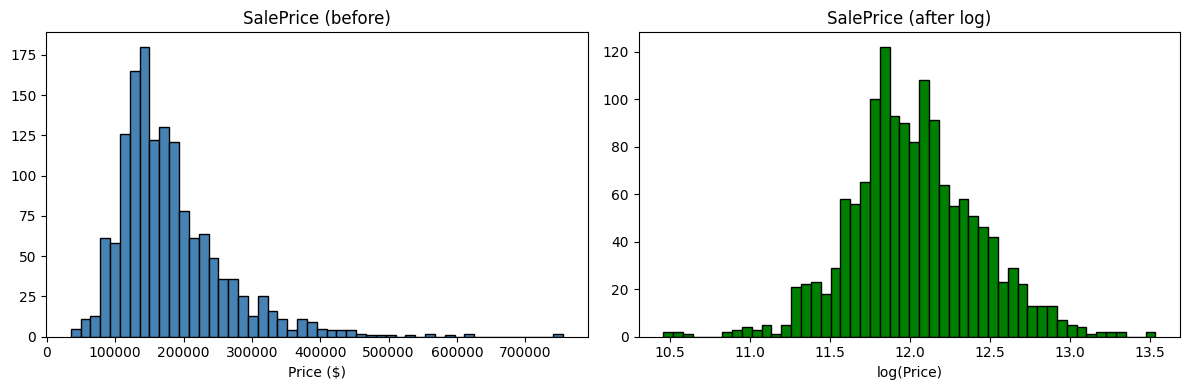

Outliers found: 3
      GrLivArea  SalePrice
523        4676     184750
1031       3082     197000
1298       5642     160000
Rows after cleaning: 1457


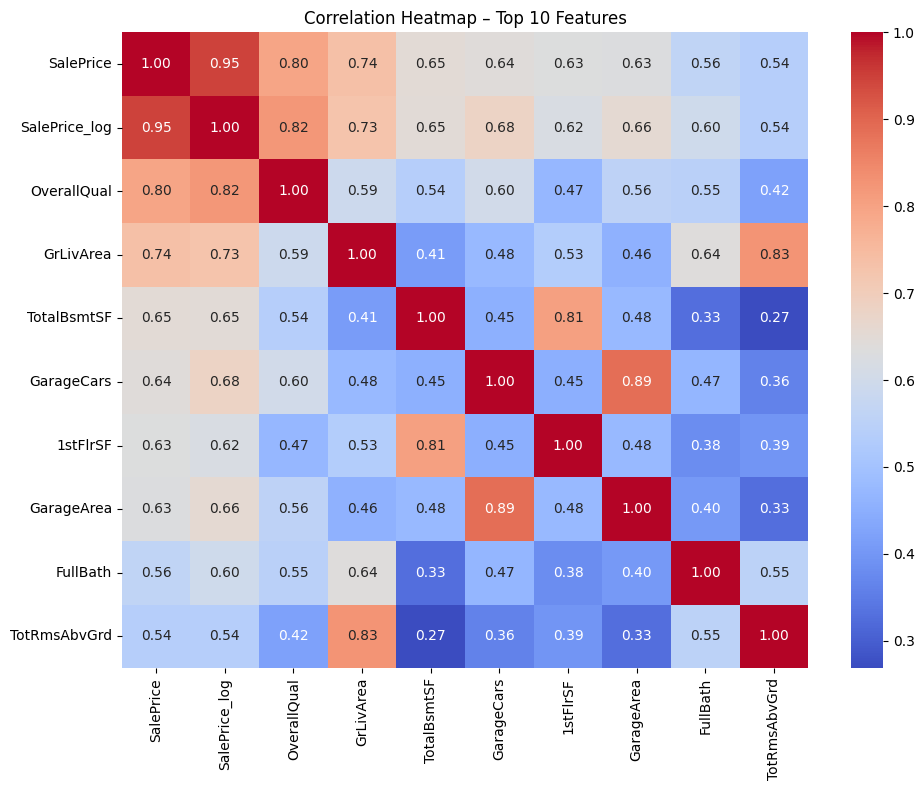

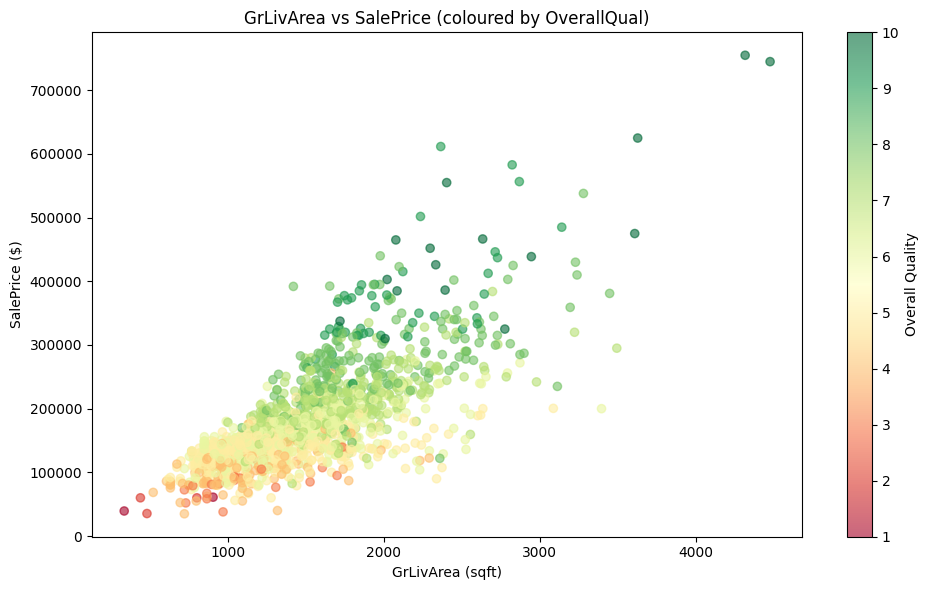

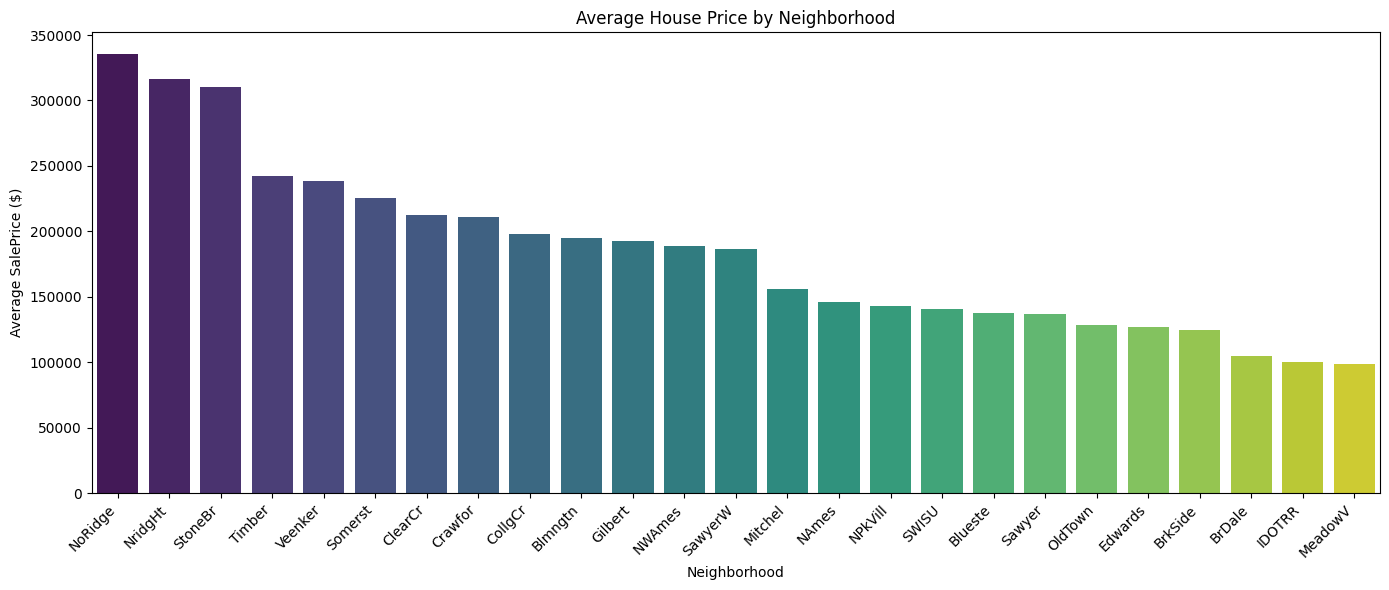


Final shape after feature engineering: (1457, 126)
✅ Data ready for modelling!


In [ ]:
# ============================================================
# Assignment 1: Data Preprocessing - House Prices
# ============================================================

# ── 1. Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


# ── 2. Data Loading ─────────────────────────────────────────
train_data = pd.read_csv('data/train.csv')
test_data  = pd.read_csv('data/test.csv')

print(f"Train shape: {train_data.shape}")
print(f"Test  shape: {test_data.shape}")
print(train_data.head())


# ── 3. Missing Value Analysis ───────────────────────────────
print("********************Missing Value Analysis**************************")
missing_values  = train_data.isnull().sum()
missing_percent = (missing_values / len(train_data)) * 100

missing_df = pd.DataFrame({
    'Feature'  : missing_values.index,
    'Count'    : missing_values.values,
    'Percent'  : missing_percent.values
})
missing_df = (missing_df[missing_df['Count'] > 0]
              .sort_values('Count', ascending=False))
print(missing_df)

# --- Fill strategies ---
# NaN here means "No feature" (not a missing value)
special_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
for col in special_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna('None')

# Numeric → median  (robust to skew)
num_cols = train_data.select_dtypes(include=[np.number]).columns
train_data[num_cols] = train_data[num_cols].fillna(train_data[num_cols].median())

# Categorical → mode
cat_cols = train_data.select_dtypes(include='object').columns
for col in cat_cols:
    if train_data[col].isnull().sum() > 0:
        train_data[col] = train_data[col].fillna(train_data[col].mode()[0])

print(f"\nRemaining missing values: {train_data.isnull().sum().sum()}")


# ── 4. Log-transform SalePrice ──────────────────────────────
train_data['SalePrice_log'] = np.log1p(train_data['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_data['SalePrice'],     bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('SalePrice (before)')
axes[0].set_xlabel('Price ($)')

axes[1].hist(train_data['SalePrice_log'], bins=50, edgecolor='black', color='green')
axes[1].set_title('SalePrice (after log)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()


# ── 5. Outlier Removal (IQR on GrLivArea) ──────────────────
Q1  = train_data['GrLivArea'].quantile(0.25)
Q3  = train_data['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Large houses with suspiciously low price = misleading for the model
outliers = train_data[
    (train_data['GrLivArea'] > upper_bound) &
    (train_data['SalePrice'] < 200_000)
]
print(f"Outliers found: {len(outliers)}")
print(outliers[['GrLivArea', 'SalePrice']])

train_data = train_data[
    ~((train_data['GrLivArea'] > upper_bound) &
      (train_data['SalePrice'] < 200_000))
]
print(f"Rows after cleaning: {train_data.shape[0]}")


# ── 6. EDA ──────────────────────────────────────────────────

# 6-a  Correlation Heatmap
corr_matrix  = train_data.select_dtypes(include=[np.number]).corr()
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[top_features].loc[top_features],
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap – Top 10 Features')
plt.tight_layout()
plt.show()

# 6-b  GrLivArea vs SalePrice coloured by OverallQual
plt.figure(figsize=(10, 6))
sc = plt.scatter(train_data['GrLivArea'], train_data['SalePrice'],
                 c=train_data['OverallQual'], cmap='RdYlGn', alpha=0.6)
plt.colorbar(sc, label='Overall Quality')
plt.xlabel('GrLivArea (sqft)')
plt.ylabel('SalePrice ($)')
plt.title('GrLivArea vs SalePrice (coloured by OverallQual)')
plt.tight_layout()
plt.show()

# 6-c  Average SalePrice by Neighbourhood
neighborhood_avg = (train_data.groupby('Neighborhood')['SalePrice']
                               .mean()
                               .sort_values(ascending=False))

plt.figure(figsize=(14, 6))
sns.barplot(x=neighborhood_avg.index, y=neighborhood_avg.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Neighborhood')
plt.ylabel('Average SalePrice ($)')
plt.title('Average House Price by Neighborhood')
plt.tight_layout()
plt.show()


# ── 7. Feature Engineering ──────────────────────────────────

# 7-a  New feature: total square footage
train_data['TotalSF'] = (train_data['TotalBsmtSF'] +
                         train_data['1stFlrSF']    +
                         train_data['2ndFlrSF'])

# 7-b  Label Encoding for ordinal features
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageQual', 'FireplaceQu']
for col in ordinal_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].map(quality_map).fillna(0).astype(int)

# 7-c  One-Hot Encoding for nominal features
nominal_cols = ['Neighborhood', 'BldgType', 'HouseStyle', 'SaleType', 'SaleCondition']
train_data = pd.get_dummies(train_data, columns=nominal_cols, drop_first=True)

print(f"\nFinal shape after feature engineering: {train_data.shape}")
print("Data ready for modelling!")